In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("./processed_map.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

(np.float64(-0.5), np.float64(6292.5), np.float64(6134.5), np.float64(-0.5))

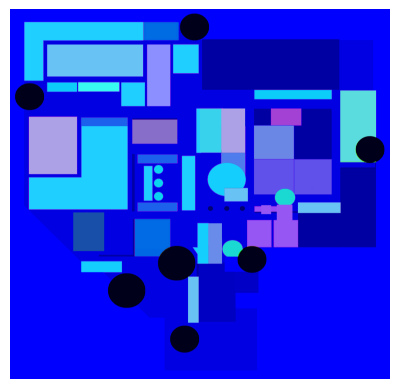

In [17]:
plt.imshow(img_hsv)
plt.axis('off')

In [19]:
plt.figure(figsize=(12, 12))  # Bigger figure → more pixels
plt.imshow(img_hsv)
plt.axis('off')

# Save with high quality
plt.savefig("exported_image.png", dpi=600, bbox_inches='tight', pad_inches=0)
plt.close()

In [18]:
# img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
thresh = cv2.adaptiveThreshold(
    img_hsv, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11, 2
)

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


error: OpenCV(4.13.0) /Users/macmini_16g/GHA-Actions-Opencv-Python/_work/opencv-python/opencv-python/opencv/modules/imgproc/src/thresh.cpp:1908: error: (-215:Assertion failed) src.type() == CV_8UC1 in function 'adaptiveThreshold'


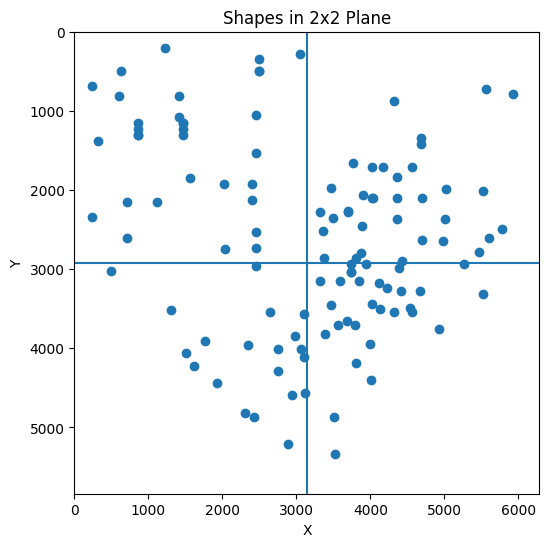

In [13]:
cv2.drawContours(img, contours, -1, (0, 255, 0), 2)

import matplotlib.pyplot as plt

h, w = img.shape[:2]

xs = []
ys = []

for cnt in contours:
    if cv2.contourArea(cnt) < 200:
        continue

    M = cv2.moments(cnt)
    if M["m00"] == 0:
        continue

    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])

    xs.append(cx)
    ys.append(cy)

# Plot
plt.figure(figsize=(6,6))
plt.scatter(xs, ys)

# 🔥 Draw 2x2 grid lines
plt.axvline(x=w/2)
plt.axhline(y=h/2)

# Match image coordinate system
plt.xlim(0, w)
plt.ylim(h, 0)  # invert Y so it matches image

plt.title("Shapes in 2x2 Plane")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()